# Major Notebook (2 of 2): Countries' Daily Temperature Statistics Over Time
This Jupyter notebook analyzes the daily temperature ranges and their trends over time. Each year is sampled twenty times, noting the average and standard deviation of temperature ranges for each country from 1980 to 2010. This notebook was created after `temp-gdp.ipynb` to emphasize some questionable features of the CMIP6 dataset.

### Step 1
The necessary packages are imported.

In [26]:
# Basic, device-agnostic data processing libraries
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.cbook import boxplot_stats
import geopandas as gpd

# Cloud-based data processing libraries
import OpenVisus as ov
from pyspark import SparkContext

# Standard library
from datetime import datetime, timedelta
from unidecode import unidecode
import math
import time
import os

# Import from utils.py
from utils import CountryFinder

### Step 2
A `DBReader` class is defined and instantiated to simplify the process of reading from the database. An example of imported data has its shape printed below.

In [27]:
class DBReader:
    def __init__(self):
        self.__db = ov.LoadDataset(
            "http://atlantis.sci.utah.edu/mod_visus?dataset=nex-gddp-cmip6"
        )
        self.__model     = "ACCESS-CM2"
        self.__scenario  = "historical"
        
        '''
        tasmax
        Daily Maximum Near-Surface Air Temperature
        Degrees Kelvin
        
        tasmin
        Daily Minimum Near-Surface Air Temperature
        Degrees Kelvin
        '''

    def __calculate_day_of_year(self, date_str):
        date = datetime.strptime(date_str, '%Y-%m-%d')
        start_of_year = datetime(date.year, 1, 1)
        day_of_year = (date - start_of_year).days   
        return day_of_year
        
    def __get_timestep(self, date_str):
        date = datetime.strptime(date_str, '%Y-%m-%d')
        day_of_year = self.__calculate_day_of_year(date_str)
        total_days = 365 + (1 if (date.year % 4 == 0 and date.year % 100 != 0) or (date.year % 400 == 0) else 0)
        return f"{date.year*total_days+day_of_year}"
        
    def read(self, timestamp, domax):
        timestep_index = int(self.__get_timestep(timestamp))
        return self.__db.read(
            time = timestep_index,
            quality = 0,
            field = f"{"tasmax" if domax else "tasmin"}_day_{self.__model}_{self.__scenario}_r1i1p1f1_gn"
        )

dbr = DBReader()
ex_min_temps = dbr.read('1980-01-01', False)
print(ex_min_temps.shape)

(600, 1440)


### Step 3
The country matrix is imported from cache/cmat.bin for later country-specific computation.

In [28]:
country_matrix = np.fromfile("cache/cmat.bin").reshape((600, 1440)).astype(np.int32)

### Step 4
Function `show_map` is defined for displaying world data as an image to confirm the earlier imported data and country matrix are valid.

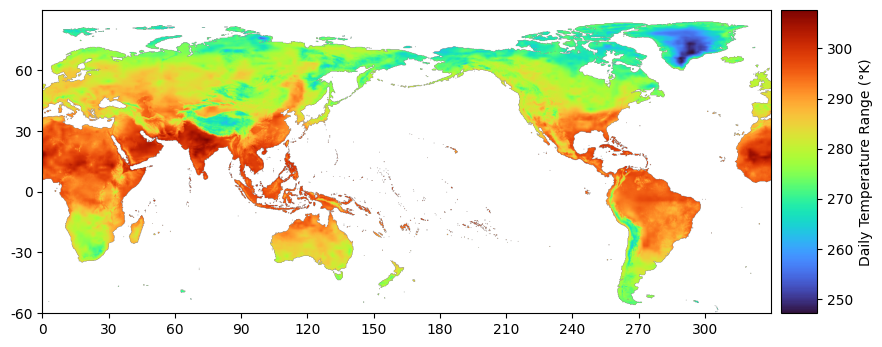

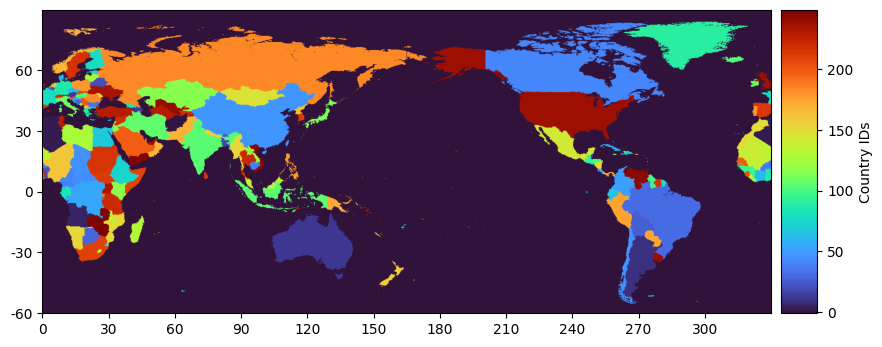

In [29]:
def show_map(data: np.ndarray, title: str):
    y_max, x_max = data.shape
    xlabels = [str(x) for x in range(0, 360, 30)]
    ylabels = [str(y) for y in range(-60, 91, 30)]
    xticks = np.linspace(0, x_max, len(xlabels))
    yticks = np.linspace(0, y_max, len(ylabels))
    
    # Create the plot
    fig, axes = plt.subplots(1, 1, figsize=(10, 8))
    axes.set_xticks(xticks)
    axes.set_xticklabels(xlabels)
    axes.set_yticks(yticks)
    axes.set_yticklabels(ylabels)
    
    # Plot the data
    im = axes.imshow(data[:, :], origin='lower', cmap='turbo')
    
    divider = make_axes_locatable(axes)
    cax = divider.append_axes("right", size="5%", pad=0.1)  # Adjust size and pad as needed
    
    # Add the colorbar
    cbar = plt.colorbar(im, cax=cax)
    cbar.set_label(title)
    
    # Show the plot
    plt.show()

show_map(ex_min_temps, 'Daily Temperature Range (°K)')
show_map(country_matrix, 'Country IDs')

### Step 3.5
Function `country_tuples` is defined, returning an `np.array` of longitude-latitude pairs to analyze for a specified country. Italy is passed for example output.

In [30]:
tuples_cache = {}
def country_tuples(country: str, country_matrix: np.array):
    if country in tuples_cache:
        return tuples_cache[country]
    
    cf = CountryFinder()
    cid = cf.name_to_cid(country)
    output = [[], []]
    for i in range(country_matrix.shape[0]):
        for j in range(country_matrix.shape[1]):
            if country_matrix[i][j] == cid:
                output[0].append(i)
                output[1].append(j)

    output = np.array(output)
    tuples_cache[country] = output
    return output

italy_tuples = country_tuples("Italy", country_matrix)
print(italy_tuples.shape)

(2, 529)


### Step 4
Function `day_stats` returns a country's average minimum and maximum daily temperature. 

In [31]:
def day_stats(timestamp: str, country: str, country_matrix: np.array):
    idx_tuples = country_tuples(country, country_matrix)
    return np.array((
        np.mean(dbr.read(timestamp, False)[idx_tuples[0], idx_tuples[1]]),
        np.mean(dbr.read(timestamp, True)[idx_tuples[0], idx_tuples[1]])
    ))

ex_temp_tuple = day_stats("1980-01-01", "Italy", country_matrix)
print(ex_temp_tuple.shape)

(2,)


### Step 6
Function `month_cstats` is defined to compute the temperature statistics for the first `n` days of the year. The statistics of the minimum, maximum, and difference between the two daily temperatures are recorded as box plots.

In [32]:
def month_cstats(year: int, country: str, n = 20):
    output = np.zeros((2, n))
    timestamps = [(datetime(year=year, month=1, day=1) + timedelta(days=x)).strftime('%Y-%m-%d') for x in range(n)]
    for i in range(len(timestamps)):
        output[:,i] = day_stats(timestamps[i], country, country_matrix)
    return (
        boxplot_stats(output[0])[0],
        boxplot_stats(output[1])[0],
        boxplot_stats(output[1] - output[0])[0]
    )

start = time.perf_counter()
m1_cstats = month_cstats(1980, "Italy", 5)
print(m1_cstats[0])
end = time.perf_counter()
elapsed = end - start
print(f"Time to compute yearly temperature stats: {elapsed:.6f} seconds")

{'mean': np.float64(286.6381103515625), 'iqr': np.float64(0.532806396484375), 'cilo': np.float64(286.71599101570985), 'cihi': np.float64(287.46418476554015), 'whishi': np.float64(287.5196228027344), 'whislo': np.float64(286.6148986816406), 'fliers': array([284.8182373]), 'q1': np.float64(286.6148986816406), 'med': np.float64(287.090087890625), 'q3': np.float64(287.147705078125)}
Time to compute yearly temperature stats: 5.146245 seconds


### Step 7
Function `months_cstats` is defined to determine the box plots for each year within a given start and stop year (from 1980 to 2010, inclusive).

In [33]:
def months_cstats(years: tuple[int, int], country: str, n = 20):
    # Index by year, country, mean/stddev
    output = []
    year_list = range(years[0], years[1]+1)
    for yr in year_list:
        print(f"Processing {yr}...", end='\r')
        output.append(month_cstats(yr, country, n))
    return output

year_tuple = (1980, 2010)
print(f"Configured to compute box plots for years in range [{year_tuple[0]}, {year_tuple[1]}].")

Configured to compute box plots for years in range [1980, 2010].


### Step 8
The box plots for minimum, maximum, and the difference between those two are computed for Italy for the years 1980 to 2010.

In [15]:
start = time.perf_counter()
italy_data = months_cstats(year_tuple, "Italy", 20)
end = time.perf_counter()
elapsed = end - start
print(f"Time to compute multi-year temperature stats: {elapsed:.6f} seconds")

Time to compute multi-year temperature stats: 624.463786 seconds


### Step 9
Function `graph_boxes` is defined to display a list of box plot parameters as a graph. Italy's temperature statistics were displayed.

In [18]:
# Create any missing directories
if not os.path.exists("plots"):
    os.mkdir("plots")
if not os.path.exists("plots/box"):
    os.mkdir("plots/box")
print("Created any missing directories.")

def graph_boxes(
    boxdata: list[dict], years: tuple[int, int],
    title: str, xlbl: str, ylbl: str,
    file_name: str
):
    year_list = np.arange(years[0], years[1]+1)
    means = [ x["mean"] for x in boxdata ]

    fig, ax = plt.subplots()
    ax.set_ylabel(ylbl)
    ax.set_xlabel(xlbl)
    ax.set_title(title)
    ax.bxp(boxdata, showmeans=True, showfliers=False)
    xticks, xlabels = plt.xticks()
    plt.plot(range(1, len(means)+1), means)
    plt.xticks(xticks[::8], year_list[::8])
    plt.savefig(f"plots/box/{file_name}")
    plt.show()
    plt.close()

Created any missing directories.


### Step 10
Italy's temperature box plots were displayed as three graphs.

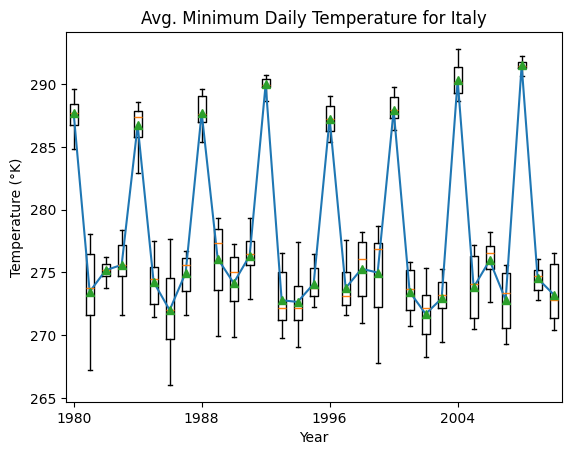

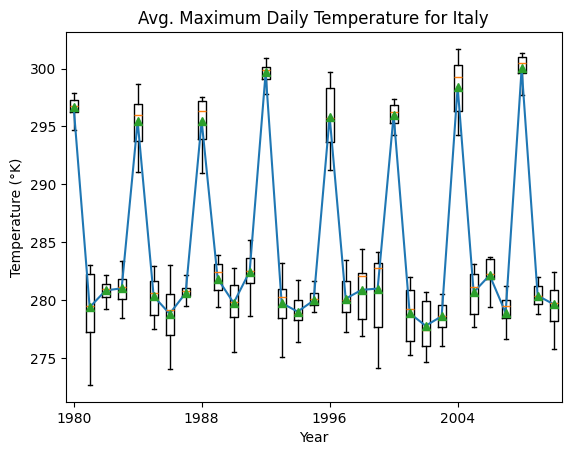

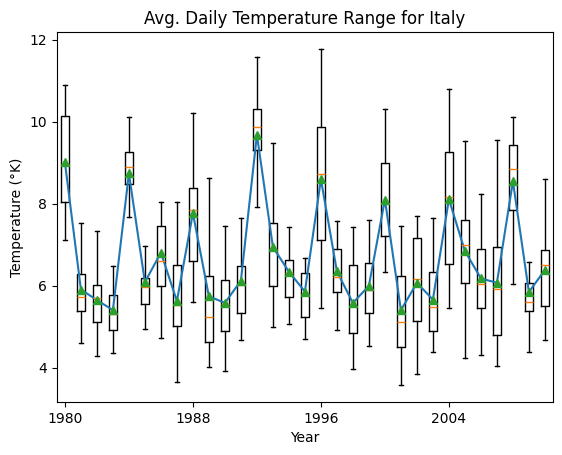

In [19]:
graph_boxes(
    [x[0] for x in italy_data], year_tuple,
    "Avg. Minimum Daily Temperature for Italy",
    "Year",
    "Temperature (°K)",
    "italy_min"
)

graph_boxes(
    [x[1] for x in italy_data], year_tuple,
    "Avg. Maximum Daily Temperature for Italy",
    "Year",
    "Temperature (°K)",
    "italy_max"
)

graph_boxes(
    [x[2] for x in italy_data], year_tuple,
    "Avg. Daily Temperature Range for Italy",
    "Year",
    "Temperature (°K)",
    "italy_diff"
)

### Step 11
The same temperature computations were performed on Angola.

In [20]:
year_tuple = (1980, 2010)
start = time.perf_counter()
angola_data = months_cstats(year_tuple, "Angola", 20)
end = time.perf_counter()
elapsed = end - start
print(f"Time to compute multi-year temperature stats: {elapsed:.6f} seconds")

Time to compute multi-year temperature stats: 623.330285 seconds


### Step 12
Angola's temperature box plot parameters were graphed.

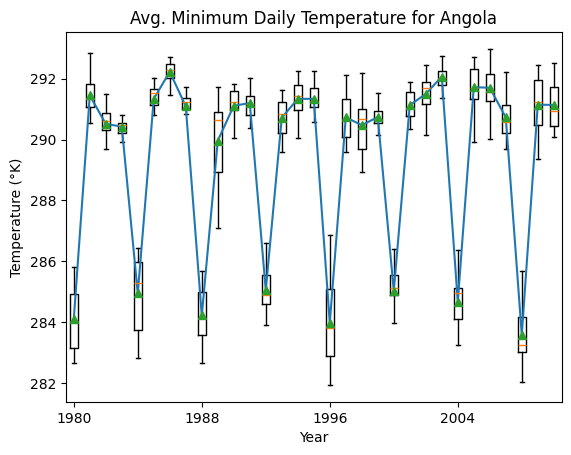

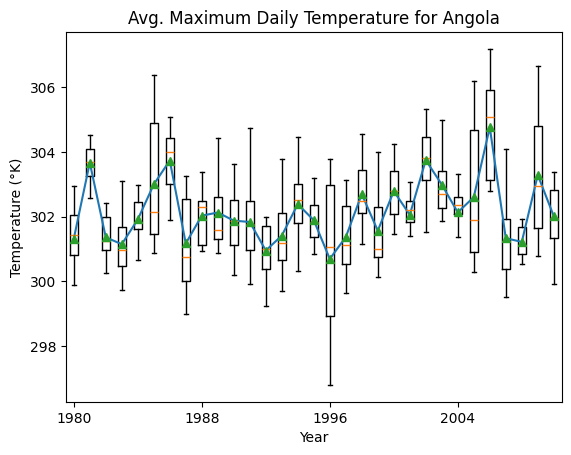

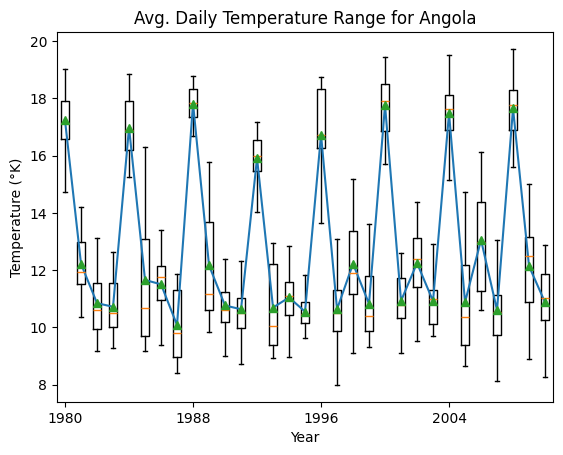

In [21]:
graph_boxes(
    [x[0] for x in angola_data], year_tuple,
    "Avg. Minimum Daily Temperature for Angola",
    "Year",
    "Temperature (°K)",
    "angola_min"
)

graph_boxes(
    [x[1] for x in angola_data], year_tuple,
    "Avg. Maximum Daily Temperature for Angola",
    "Year",
    "Temperature (°K)",
    "angola_max"
)

graph_boxes(
    [x[2] for x in angola_data], year_tuple,
    "Avg. Daily Temperature Range for Angola",
    "Year",
    "Temperature (°K)",
    "angola_diff"
)

### Step 13
The same temperature computations were performed on Kazakhstan.

In [23]:
year_tuple = (1980, 2010)
start = time.perf_counter()
kazakhstan_data = months_cstats(year_tuple, "Kazakhstan", 20)
end = time.perf_counter()
elapsed = end - start
print(f"Time to compute multi-year temperature stats: {elapsed:.6f} seconds")

Time to compute multi-year temperature stats: 623.740548 seconds


### Step 14
Kazakhstan's temperature box plot parameters were graphed.

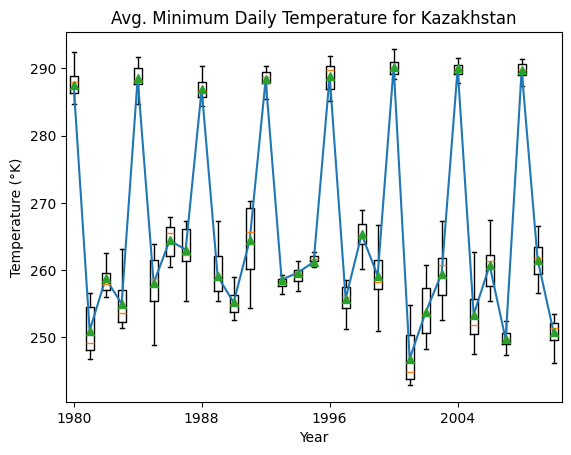

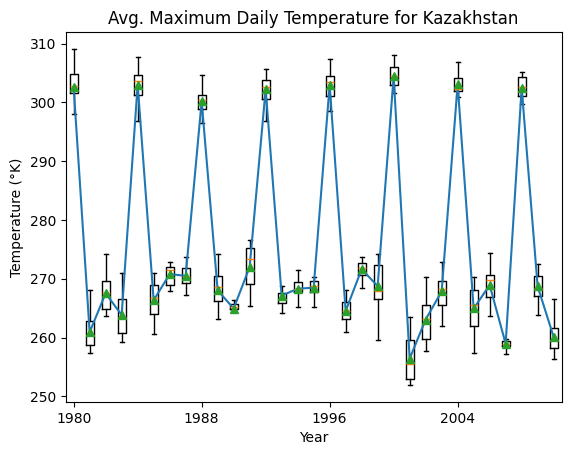

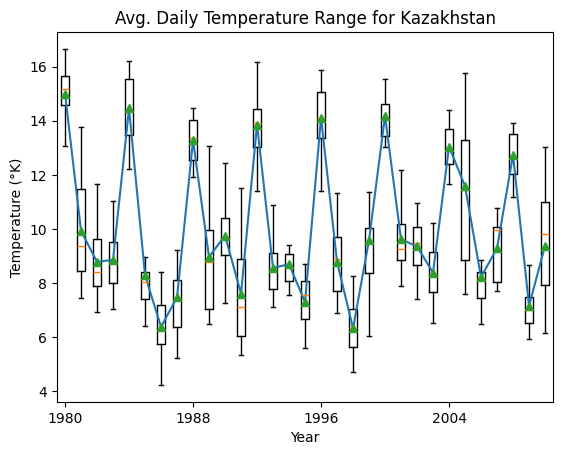

In [25]:
graph_boxes(
    [x[0] for x in kazakhstan_data], year_tuple,
    "Avg. Minimum Daily Temperature for Kazakhstan",
    "Year",
    "Temperature (°K)",
    "kazakhstan_min"
)

graph_boxes(
    [x[1] for x in kazakhstan_data], year_tuple,
    "Avg. Maximum Daily Temperature for Kazakhstan",
    "Year",
    "Temperature (°K)",
    "kazakhstan_max"
)

graph_boxes(
    [x[2] for x in kazakhstan_data], year_tuple,
    "Avg. Daily Temperature Range for Kazakhstan",
    "Year",
    "Temperature (°K)",
    "kazakhstan_diff"
)